# End-to-End Sales Forecasting & Demand Intelligence System



## Project Overview

Accurate sales forecasting is a critical component of retail and e-commerce businesses. Predicting future demand helps organizations optimize inventory levels, reduce operational costs, improve customer satisfaction, and maximize revenue.

This project develops an end-to-end Sales Forecasting and Demand Intelligence System using historical sales data. The system performs exploratory data analysis, time series forecasting, anomaly detection, demand segmentation, and provides an interactive business dashboard.

The project compares three forecasting techniques:

- SARIMA (Statistical Forecasting)
- Facebook Prophet (Additive Time Series Model)
- XGBoost (Machine Learning)

The best-performing model is selected based on evaluation metrics and used to forecast product categories and regional sales. Additionally, anomaly detection and clustering techniques are applied to generate actionable business insights.

Finally, the entire solution is deployed as an interactive Streamlit dashboard for business users.

## Project Objectives

The objectives of this project are:

- Perform comprehensive exploratory data analysis.
- Identify sales trends and seasonality.
- Build and compare three forecasting models.
- Forecast future product demand.
- Detect unusual sales behaviour.
- Segment products based on demand patterns.
- Develop an interactive dashboard using Streamlit.
- Generate business recommendations for inventory planning.

## Workflow

The project follows the workflow below:

1. Data Loading
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Time Series Analysis
6. Sales Forecasting
7. Model Comparison
8. Category Forecasting
9. Region Forecasting
10. Anomaly Detection
11. Product Demand Segmentation
12. Dashboard Development
13. Business Report

# Import Required Libraries

This section imports all the libraries required throughout the project for data preprocessing, visualization, forecasting, anomaly detection, clustering, and model evaluation.

In [1]:
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet
from prophet import Prophet

# XGBoost
from xgboost import XGBRegressor

# Save Models
import joblib

In [2]:
# Plotting Style
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

# Set figure size
plt.rcParams["figure.figsize"] = (12,6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load the Dataset

The primary dataset used in this project is the Superstore Sales dataset. It contains transactional information such as order dates, sales, profit, category, sub-category, region, and customer information.

The dataset covers four years of historical sales, making it suitable for time series forecasting.

In [3]:
# Load dataset

df = pd.read_csv("train.csv")

In [4]:
# First five rows

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# Last five rows

df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [6]:
# Dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9800
Columns : 18


In [7]:
# Column names

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [8]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
# Statistical Summary

df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [10]:
# Check missing values

df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [11]:
# Duplicate rows

df.duplicated().sum()

np.int64(0)

## Initial Observations

- The dataset contains historical retail transactions.
- Date columns require conversion into datetime format.
- Missing values and duplicate records will be handled in the next section.
- Further feature engineering is required before time series analysis.

# Data Cleaning

Before performing any analysis, the dataset must be cleaned to ensure consistency and accuracy.

The following preprocessing steps are performed:

- Convert date columns into datetime format
- Check and remove duplicate records
- Handle missing values
- Verify data types
- Create additional time-based features

In [12]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [13]:
# Check missing values

missing = df.isnull().sum()

missing[missing > 0]

Postal Code    11
dtype: int64

In [14]:
# Check duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [15]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset Shape :", df.shape)

Dataset Shape : (9800, 18)


In [16]:
# Convert date columns into datetime

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

print("Date Conversion Successful")

Date Conversion Successful


In [17]:
# Verify Data Types

df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

## Observation

The Order Date and Ship Date columns have been successfully converted into datetime format, enabling time-based analysis and forecasting.

# Feature Engineering

To support time series analysis, several temporal features are extracted from the Order Date.

These include:

- Year
- Month
- Month Name
- Quarter
- Week Number
- Day of Week
- Season
- Shipping Duration

In [18]:
# Extract Year

df["Year"] = df["Order Date"].dt.year

In [19]:
# Extract Month Number

df["Month"] = df["Order Date"].dt.month

In [20]:
# Month Name

df["Month Name"] = df["Order Date"].dt.month_name()

In [21]:
# Quarter

df["Quarter"] = df["Order Date"].dt.quarter

In [22]:
# Week Number

df["Week"] = df["Order Date"].dt.isocalendar().week

In [23]:
# Day of Week

df["Day"] = df["Order Date"].dt.day_name()

In [24]:
# Shipping Duration

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [25]:
# Create Season Feature

def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [26]:
# View Updated Dataset

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Shipping Days,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,3,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,3,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,4,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,7,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,7,Autumn


# Sales Aggregation

Forecasting models require aggregated time series.

The dataset is aggregated into:

- Daily Sales
- Weekly Sales
- Monthly Sales

In [27]:
# Daily Sales

daily_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [28]:
# Weekly Sales

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [29]:
# Monthly Sales

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [30]:
print("Daily Records :", daily_sales.shape)

print("Weekly Records :", weekly_sales.shape)

print("Monthly Records :", monthly_sales.shape)

Daily Records : (1230, 2)
Weekly Records : (209, 2)
Monthly Records : (48, 2)


# Save Processed Dataset

The cleaned dataset is saved for future use in forecasting and dashboard development.

In [31]:
df.to_csv("processed_sales.csv", index=False)

print("Processed Dataset Saved Successfully")

Processed Dataset Saved Successfully


# Business Questions

This section answers important business questions using the cleaned dataset.

These insights help business managers understand sales behaviour before forecasting.

## Business Question 1

### Which product category generates the highest total revenue?


In [32]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

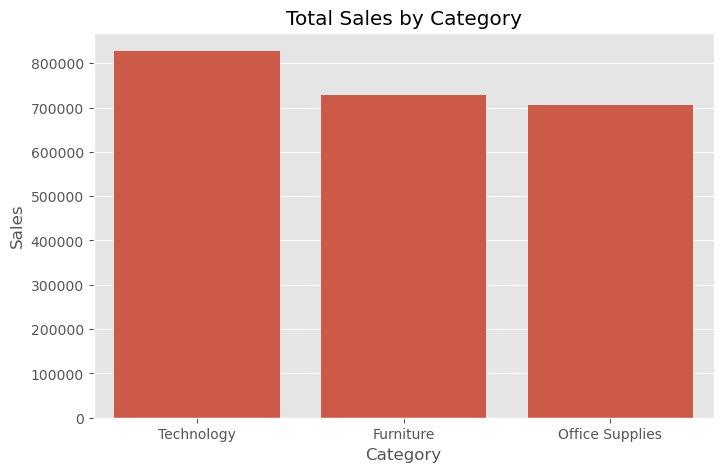

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

### Observation

From the above chart, identify the category with the highest cumulative sales and briefly explain what this indicates for inventory planning and business priorities.

## Business Question 2

### Which region has the most consistent sales growth?

In [34]:
region_year = (
    df.groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)

region_year.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


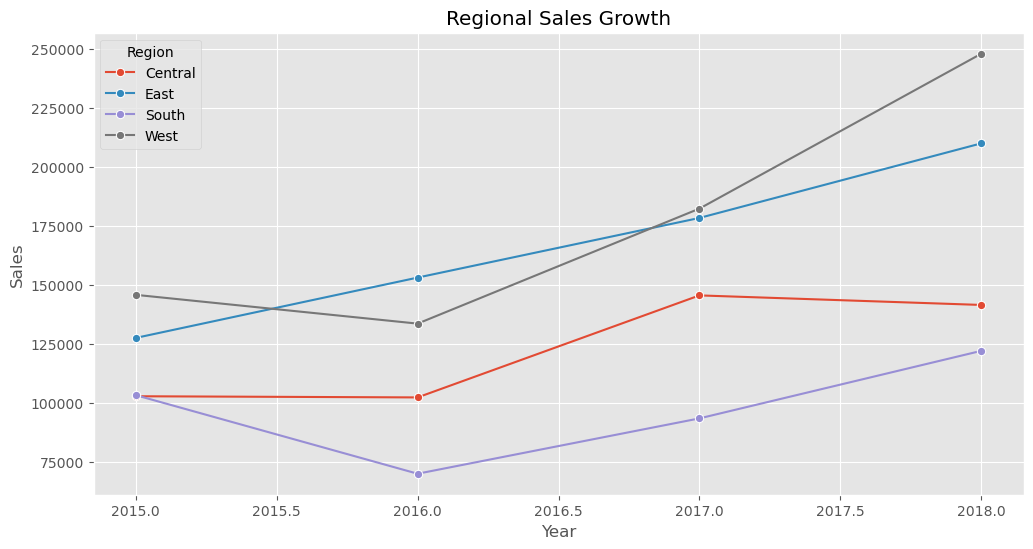

In [35]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth")

plt.show()

### Observation

Compare the year-over-year sales trend for each region and identify the region with the most stable and consistent growth.

## Business Question 3
### Average Shipping Time

In [36]:
shipping = (
    df.groupby("Region")["Shipping Days"]
    .mean()
)

shipping

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

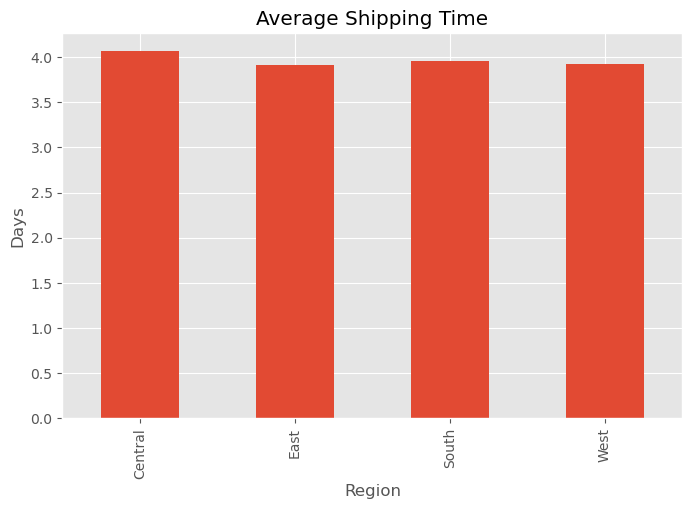

In [37]:
plt.figure(figsize=(8,5))

shipping.plot(kind="bar")

plt.ylabel("Days")

plt.title("Average Shipping Time")

plt.show()

### Observation

Discuss whether average shipping time differs across regions and mention which region has the shortest and longest average delivery duration.

## Business Question 4
### Monthly Seasonality

In [38]:
month_sales = (
    df.groupby("Month Name")["Sales"]
    .sum()
    .reindex([
        "January","February","March",
        "April","May","June",
        "July","August","September",
        "October","November","December"
    ])
)

month_sales

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

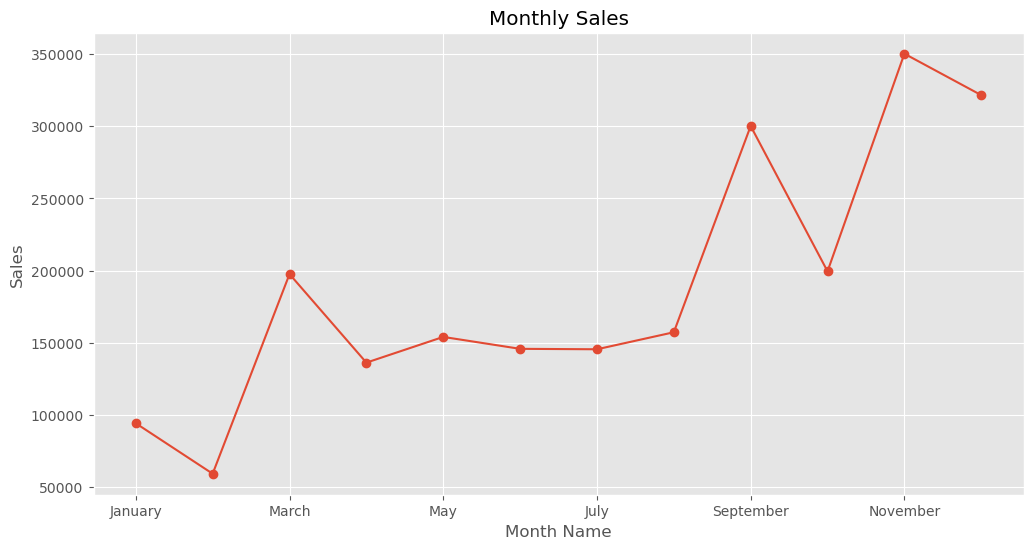

In [39]:
plt.figure(figsize=(12,6))

month_sales.plot(marker="o")

plt.title("Monthly Sales")

plt.ylabel("Sales")

plt.show()

### Observation

Identify the months that consistently generate higher sales. Discuss whether there appears to be a seasonal pattern that may influence future forecasting.

# Time Series Analysis

Time series analysis studies data collected over time to identify patterns such as trends, seasonality, and irregular fluctuations.

In this section, we will:

- Visualize monthly sales trends
- Decompose the time series into trend, seasonal, and residual components
- Perform the Augmented Dickey-Fuller (ADF) Test to check stationarity
- Apply differencing if required

In [40]:
# Prepare monthly time series

monthly_ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
)

monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [41]:
monthly_ts.tail()

Order Date
2018-08-31     62837.8480
2018-09-30     86152.8880
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

The monthly aggregated sales series will be used throughout the forecasting section of this project.

# Overall Monthly Sales Trend

Visualizing historical sales allows us to identify long-term growth patterns and recurring seasonal behaviour.

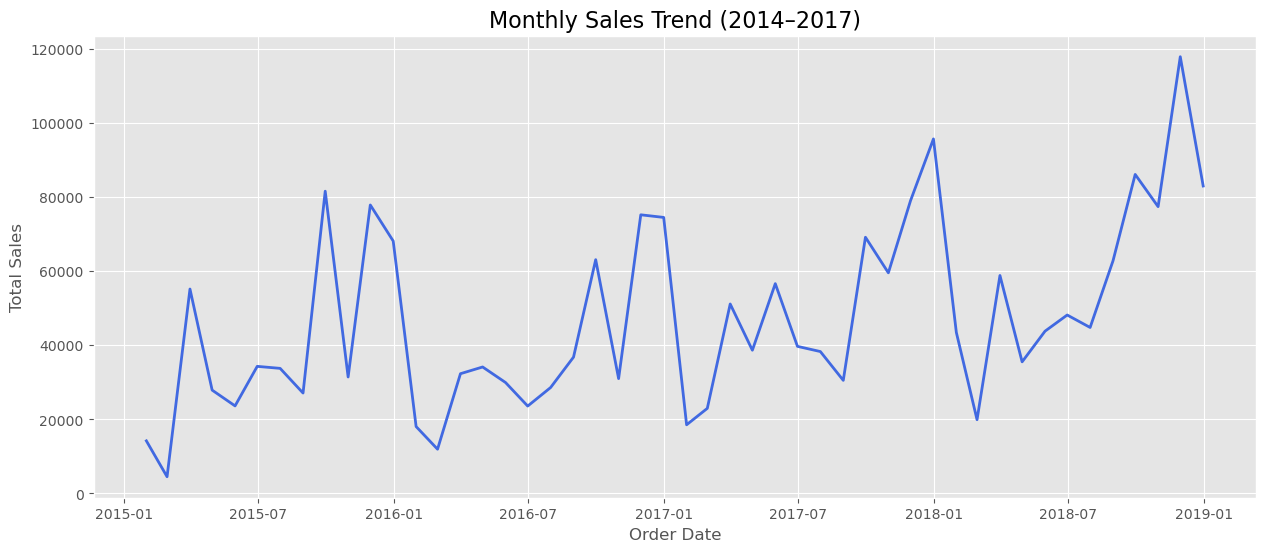

In [42]:
plt.figure(figsize=(15,6))

plt.plot(monthly_ts,
         color='royalblue',
         linewidth=2)

plt.title("Monthly Sales Trend (2014–2017)", fontsize=16)

plt.xlabel("Order Date")

plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

## Observation

Write 3–4 observations after viewing the plot.

Example points:

- Sales show an overall increasing trend.
- Several recurring peaks appear toward the end of each year.
- Some months exhibit unusually high sales.
- Seasonal behaviour appears to be present.

# Time Series Decomposition

A time series can be decomposed into four components:

1. Observed
2. Trend
3. Seasonal
4. Residual

This helps separate long-term growth from repeating seasonal effects and random fluctuations.

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [44]:
decomposition = seasonal_decompose(
    monthly_ts,
    model='additive',
    period=12
)

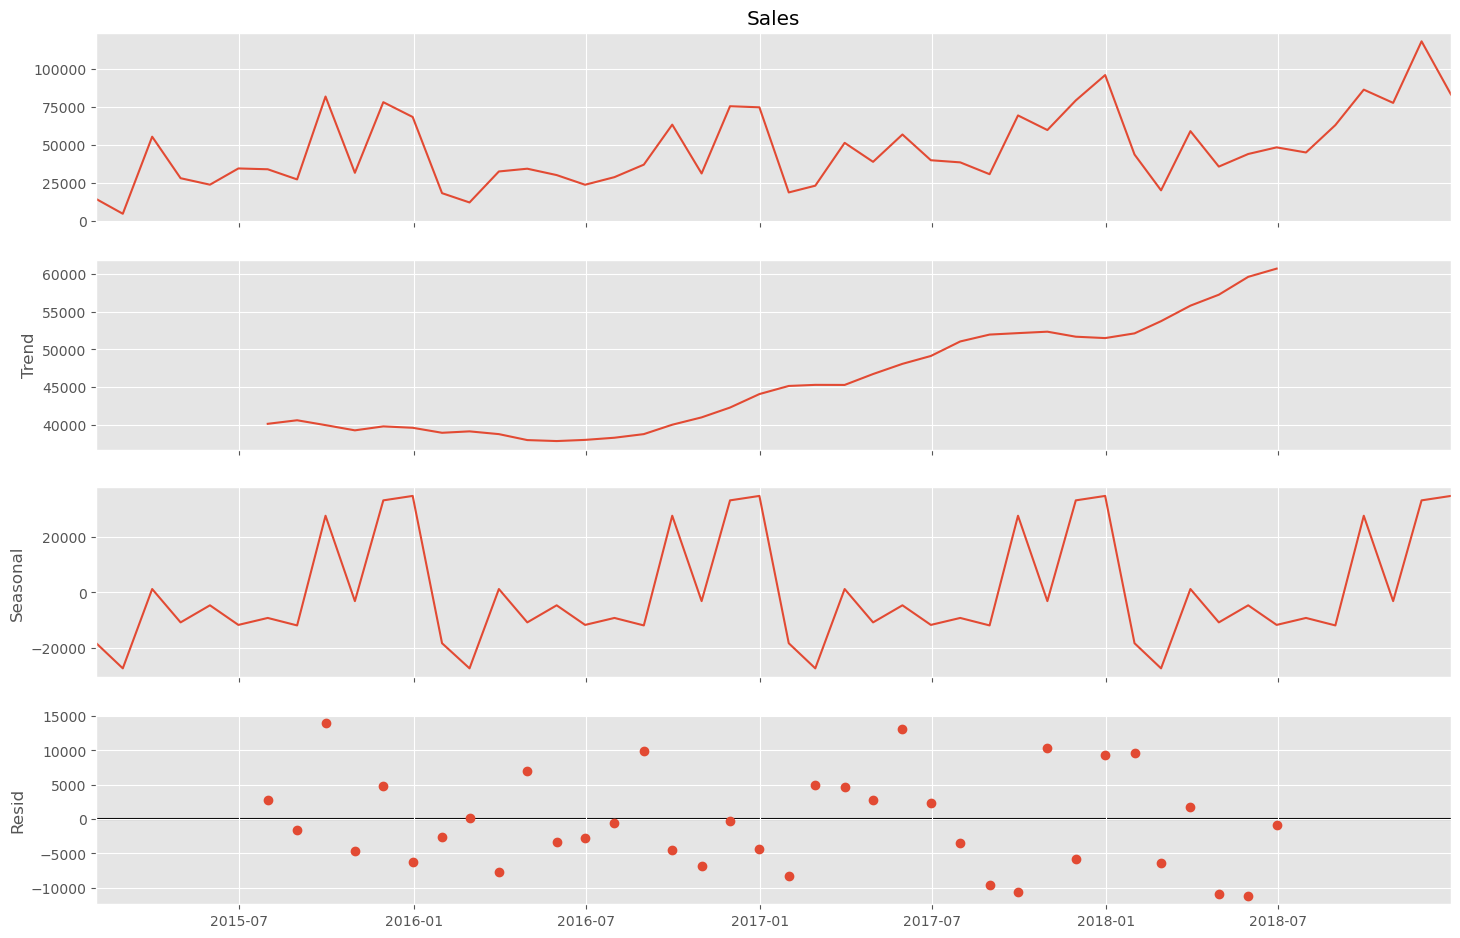

In [45]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

## Interpretation of Components

### Trend
Shows the long-term increase or decrease in sales over time.

### Seasonal
Represents recurring yearly patterns in sales.

### Residual
Shows irregular fluctuations that cannot be explained by trend or seasonality.

## Business Observations

Write observations such as:

- The trend component shows steady business growth.
- Strong seasonality indicates predictable monthly demand.
- Residual spikes may correspond to promotional campaigns or holidays.

# Stationarity Test

Most statistical forecasting models assume that the time series is stationary.

A stationary time series has:

- Constant mean
- Constant variance
- No changing trend over time

We use the Augmented Dickey-Fuller (ADF) Test to determine whether the sales series is stationary.

In [46]:
from statsmodels.tsa.stattools import adfuller

In [47]:
result = adfuller(monthly_ts)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


## Interpretation

Decision Rule:

- p-value < 0.05 → Stationary
- p-value ≥ 0.05 → Non-Stationary

In [48]:
if result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

The time series is Stationary.


# Differencing

If the series is non-stationary, first-order differencing is applied to remove the trend.

Differencing computes the change between consecutive observations.

In [49]:
monthly_diff = monthly_ts.diff().dropna()

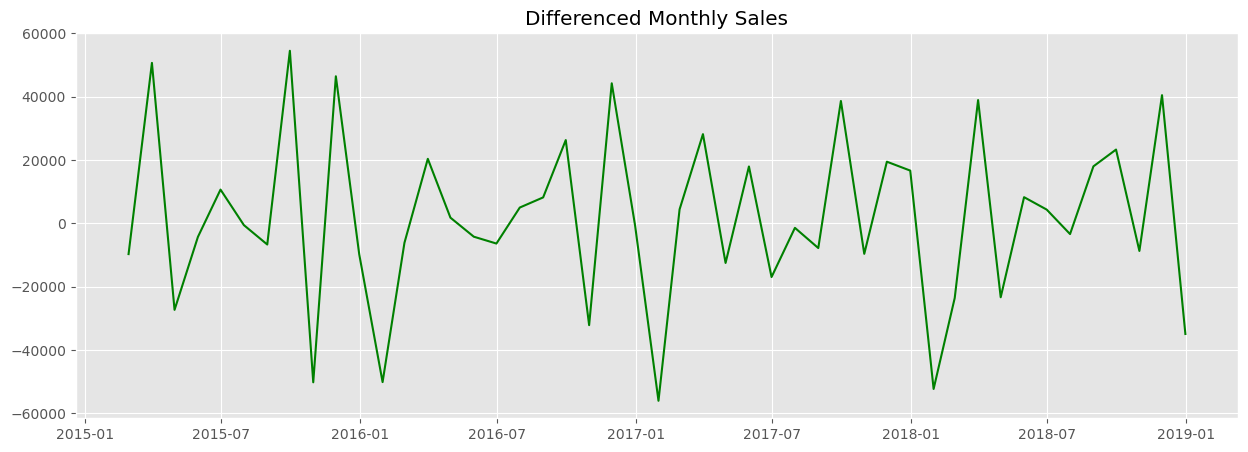

In [50]:
plt.figure(figsize=(15,5))

plt.plot(monthly_diff,
         color='green')

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

The differenced series should fluctuate around zero, indicating that the long-term trend has been removed.

In [51]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :", result2[0])

print("p-value :", result2[1])

ADF Statistic : -8.727061830353271
p-value : 3.266917547279569e-14


In [52]:
if result2[1] < 0.05:
    print("Differenced series is now Stationary.")
else:
    print("Series is still Non-Stationary.")

Differenced series is now Stationary.


## Conclusion

If the differenced series is stationary, it can be used with statistical forecasting models such as SARIMA.

The differencing order (**d**) selected here will also be used during model building.

# Sales Forecasting

Forecasting future sales is a key business requirement for inventory planning, supply chain management, and budgeting.

Three different forecasting approaches are implemented:

1. SARIMA (Statistical Model)
2. Facebook Prophet (Additive Time Series Model)
3. XGBoost (Machine Learning Model)

The performance of each model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

The best-performing model is selected for category-wise and region-wise forecasting.

## Train-Test Split

The last three months of sales data are reserved for testing, while the earlier observations are used for training the forecasting models.

In [53]:
train = monthly_ts.iloc[:-3]

test = monthly_ts.iloc[-3:]

print("Training observations :", len(train))

print("Testing observations :", len(test))

Training observations : 45
Testing observations : 3


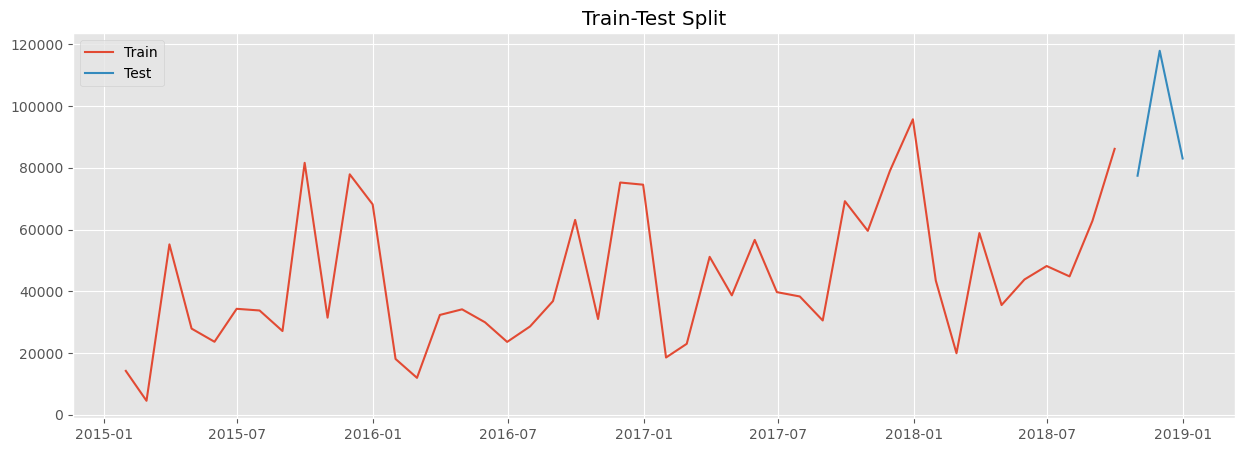

In [54]:
plt.figure(figsize=(15,5))

plt.plot(train,label="Train")

plt.plot(test,label="Test")

plt.legend()

plt.title("Train-Test Split")

plt.show()

# Model 1 — SARIMA

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical forecasting model capable of modeling both trend and seasonal patterns.

Since retail sales often exhibit yearly seasonality, SARIMA is an appropriate baseline model.

### Parameter Selection

Based on the stationarity test and the observed yearly seasonality, the following parameters are used:

- (p, d, q) = (1,1,1)
- Seasonal (P, D, Q, m) = (1,1,1,12)

These parameters provide a reasonable starting point for monthly sales forecasting.

In [55]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Fri, 10 Jul 2026   AIC                            705.958
Time:                                    22:47:09   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [56]:
sarima_forecast = sarima_model.forecast(steps=3)

sarima_forecast

2018-10-31    66177.602485
2018-11-30    92049.249693
2018-12-31    99965.168738
Freq: ME, Name: predicted_mean, dtype: float64

In [57]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

sarima_mae = mean_absolute_error(test,sarima_forecast)

sarima_rmse = np.sqrt(mean_squared_error(test,sarima_forecast))

sarima_mape = mean_absolute_percentage_error(test,sarima_forecast)

print("MAE :",sarima_mae)

print("RMSE :",sarima_rmse)

print("MAPE :",sarima_mape)

MAE : 18031.404653580652
RMSE : 19009.182053951743
MAPE : 0.18966498045554667


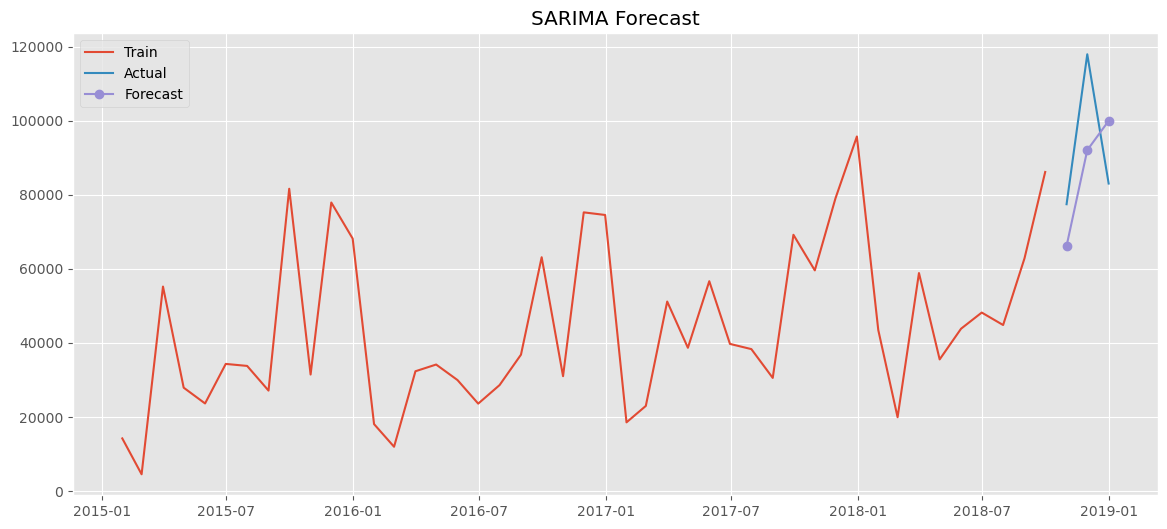

In [58]:
plt.figure(figsize=(14,6))

plt.plot(train,label="Train")

plt.plot(test,label="Actual")

plt.plot(test.index,
         sarima_forecast,
         label="Forecast",
         marker="o")

plt.legend()

plt.title("SARIMA Forecast")

plt.savefig("charts/sarima_forecast.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [59]:
forecast_obj = sarima_model.get_forecast(steps=3)

sarima_forecast = forecast_obj.predicted_mean

conf_int = forecast_obj.conf_int()

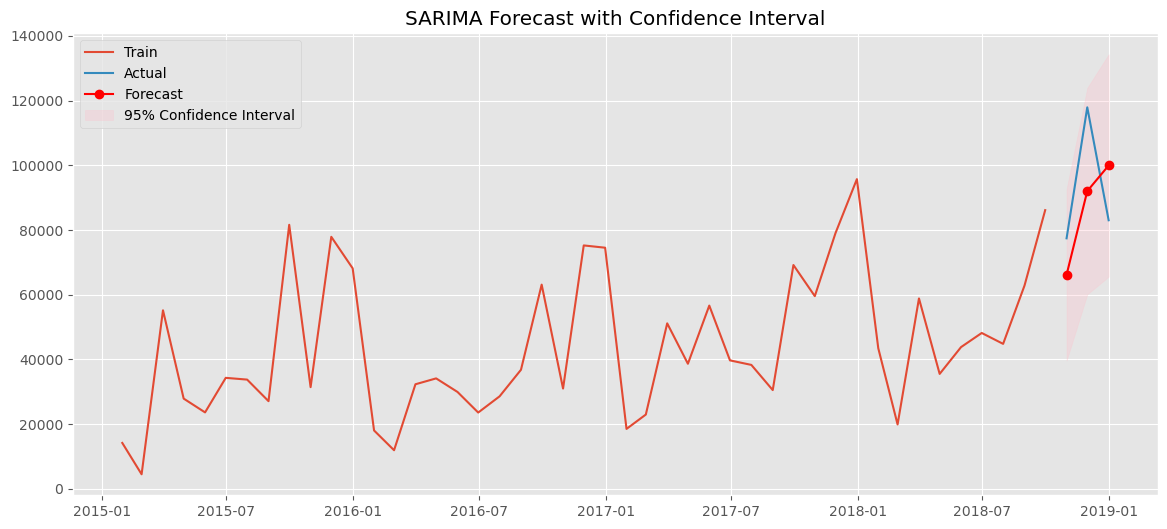

In [60]:
plt.figure(figsize=(14,6))

plt.plot(train,label="Train")

plt.plot(test,label="Actual")

plt.plot(test.index,
         sarima_forecast,
         color="red",
         marker="o",
         label="Forecast")

plt.fill_between(
    test.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.legend()

plt.title("SARIMA Forecast with Confidence Interval")

plt.grid(True)

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Model 2 — Facebook Prophet

Facebook Prophet is an additive time series forecasting model developed by Meta. It is designed to handle trend, seasonality, and holiday effects with minimal parameter tuning.

Prophet expects the dataset in a specific format:
- **ds** → Date column
- **y** → Target variable (Sales)

In this project, Prophet is trained on the monthly sales data and used to forecast the next three months.

In [61]:
prophet_df = monthly_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [62]:
prophet_train = prophet_df.iloc[:-3]

prophet_test = prophet_df.iloc[-3:]

The last three months are kept as the testing set to evaluate forecasting performance.

In [63]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_train)

22:47:23 - cmdstanpy - INFO - Chain [1] start processing
22:47:23 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
future = model.make_future_dataframe(
    periods=3,
    freq='M'
)

future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [65]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33308.214631,6018.608730,22465.300007,33308.214631,33308.214631,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,0.0,0.0,0.0,14433.784960
1,2015-02-28,33767.643626,-5406.913887,11325.339098,33767.643626,33767.643626,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,0.0,0.0,0.0,2898.100522
2,2015-03-31,34276.297157,44245.516295,60344.636020,34276.297157,34276.297157,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,0.0,0.0,0.0,52166.734451
3,2015-04-30,34768.542510,12929.262333,28705.564935,34768.542510,34768.542510,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,0.0,0.0,0.0,21107.291263
4,2015-05-31,35277.196041,14759.969162,31691.971540,35277.196041,35277.196041,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,0.0,0.0,0.0,22878.565600


In [66]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,39096.667888,55412.064208,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78217.679239,94775.865874,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,42731.074493,60217.967859,55957.448199,55957.721017,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82162.516370,98606.997649,56456.452055,56457.365921,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,81512.053463,98531.118015,56971.870975,56973.812653,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


In [67]:
prophet_forecast = forecast["yhat"].tail(3).values

prophet_forecast

array([51318.94385792, 90325.65478355, 90041.08447929])

In [68]:
prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_forecast
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_forecast
    )
)

prophet_mape = mean_absolute_percentage_error(
    prophet_test["y"],
    prophet_forecast
)

print("MAE :", prophet_mae)
print("RMSE :", prophet_rmse)
print("MAPE :", prophet_mape)

MAE : 20250.794412605526
RMSE : 22318.411332860545
MAPE : 0.21864628273960826


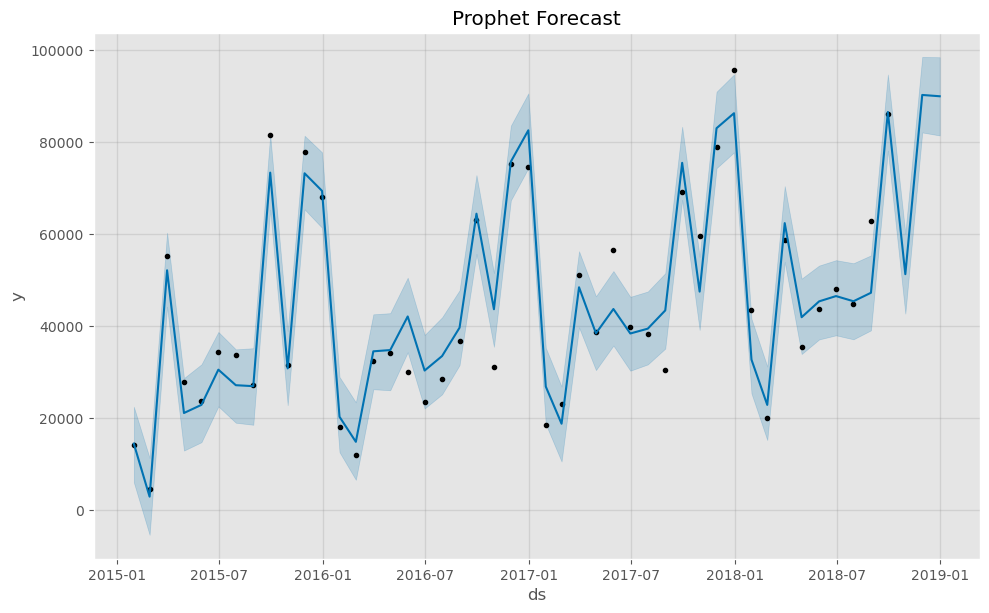

In [69]:
fig = model.plot(forecast)

plt.title("Prophet Forecast")

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Prophet Trend & Seasonality

Prophet automatically decomposes the forecast into:

- Trend
- Yearly Seasonality

These components help understand recurring demand patterns.

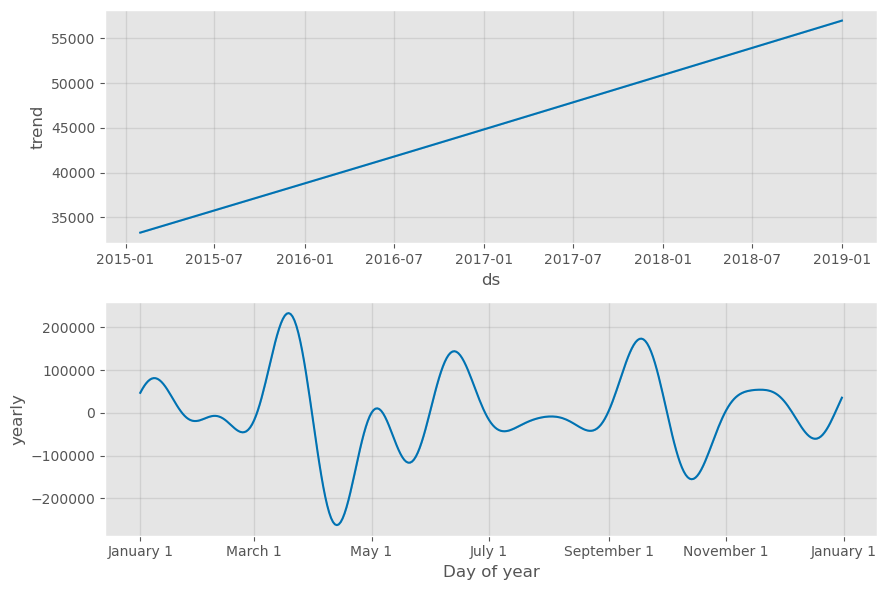

In [70]:
fig2 = model.plot_components(forecast)

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

The Prophet decomposition provides valuable insights into the sales behaviour:

- **Trend:** Indicates the long-term direction of sales.
- **Yearly Seasonality:** Highlights recurring annual demand patterns.
- **Forecast:** Provides expected sales for the next three months.

The confidence intervals indicate the uncertainty associated with each forecast.

In [71]:
joblib.dump(
    model,
    "models/prophet.pkl"
)

['models/prophet.pkl']

# Model 3 — XGBoost Regressor

Unlike SARIMA and Prophet, XGBoost is a machine learning algorithm that does not inherently understand time.

To use XGBoost for forecasting, the time series is converted into a supervised learning problem by creating lag features and rolling statistics.

The following features are used:

- Lag 1
- Lag 2
- Lag 3
- Rolling Mean (3 Months)
- Month
- Quarter
- Year

The model is trained on historical observations and evaluated on the last three months.

In [72]:
xgb_df = monthly_ts.reset_index()

xgb_df.columns = ["Date", "Sales"]

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [73]:
xgb_df["Month"] = xgb_df["Date"].dt.month

xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

xgb_df["Year"] = xgb_df["Date"].dt.year

## Lag Features

Lag features allow the model to learn how previous months influence future sales.

In [74]:
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

In [75]:
xgb_df["RollingMean3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

In [76]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Month,Quarter,Year,Lag1,Lag2,Lag3,RollingMean3
3,2015-04-30,27906.8550,4,2,2015,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-31,23644.3030,5,2,2015,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-30,34322.9356,6,2,2015,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-31,33781.5430,7,3,2015,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-31,27117.5365,8,3,2015,33781.5430,34322.9356,23644.303,31740.671700


In [77]:
X = xgb_df[
    [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean3",
        "Month",
        "Quarter",
        "Year"
    ]
]

y = xgb_df["Sales"]

In [78]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [79]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [80]:
xgb_forecast = xgb.predict(X_test)

xgb_forecast

array([89194.11 , 86949.586, 85946.69 ], dtype=float32)

In [81]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_forecast
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_forecast
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_forecast
)

print("MAE :", xgb_mae)

print("RMSE :", xgb_rmse)

print("MAPE :", xgb_mape)

MAE : 15216.948645833332
RMSE : 19207.326847989803
MAPE : 0.14984616175374038


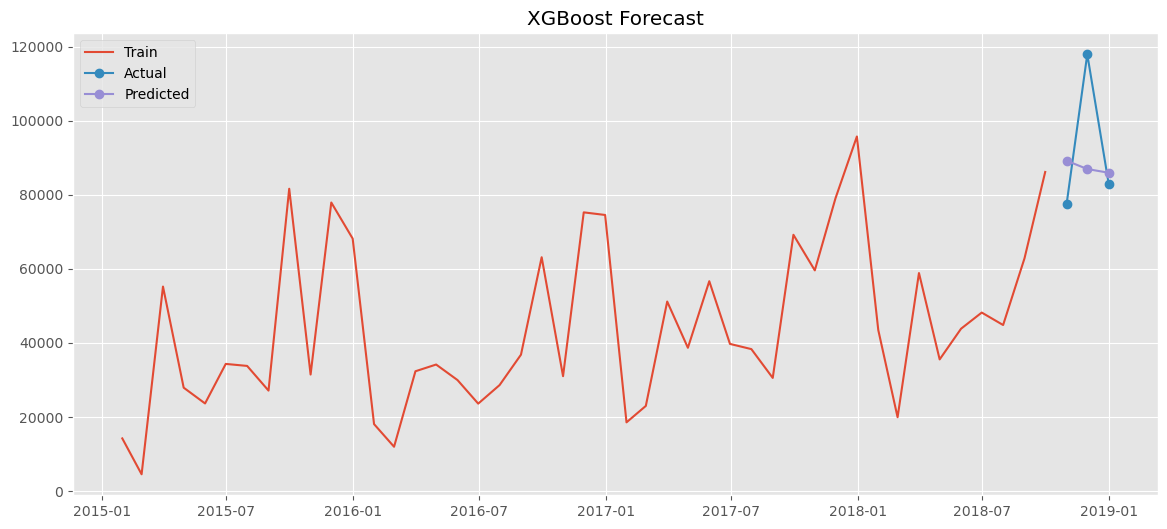

In [82]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train.values,
    label="Train"
)

plt.plot(
    test.index,
    test.values,
    label="Actual",
    marker="o"
)

plt.plot(
    test.index,
    xgb_forecast,
    label="Predicted",
    marker="o"
)

plt.legend()

plt.grid(True)

plt.title("XGBoost Forecast")

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance

Feature importance helps identify which variables contribute the most to sales prediction.

Understanding these relationships improves model interpretability and supports business decision-making.

In [83]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

importance

Month           0.824913
RollingMean3    0.059078
Year            0.055066
Lag2            0.027875
Lag1            0.024688
Lag3            0.008381
Quarter         0.000000
dtype: float32

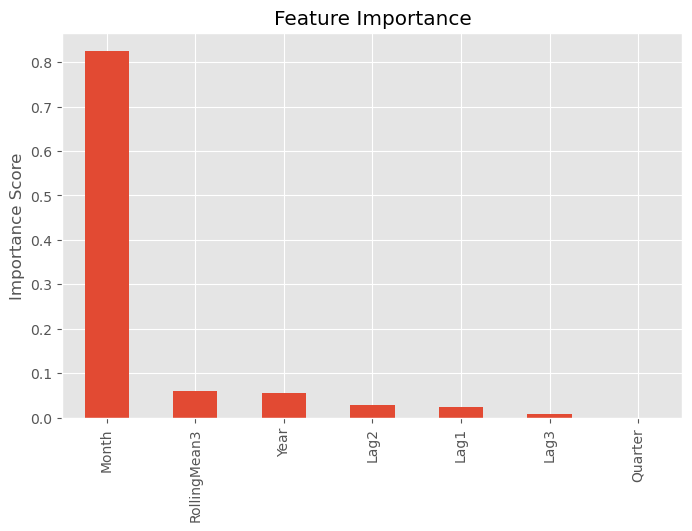

In [84]:
plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.grid(True)

plt.savefig(
    "charts/xgb_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

The feature importance chart indicates which historical sales features have the greatest influence on future sales predictions.

Typically, recent lag values and rolling averages contribute the most, demonstrating that recent sales history is a strong predictor of future demand.

In [85]:
joblib.dump(
    xgb,
    "models/xgboost.pkl"
)

['models/xgboost.pkl']

# Model Comparison

Three forecasting models were implemented:

- SARIMA
- Facebook Prophet
- XGBoost

The models are evaluated using the following metrics:

- **MAE (Mean Absolute Error):** Average prediction error.
- **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors.
- **MAPE (Mean Absolute Percentage Error):** Percentage error relative to actual values.

Lower values indicate better forecasting performance.

In [86]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape],
    "Forecast Month 1": [
        sarima_forecast.iloc[0],
        prophet_forecast[0],
        xgb_forecast[0]
    ],
    "Forecast Month 2": [
        sarima_forecast.iloc[1],
        prophet_forecast[1],
        xgb_forecast[1]
    ],
    "Forecast Month 3": [
        sarima_forecast.iloc[2],
        prophet_forecast[2],
        xgb_forecast[2]
    ]
})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404654,19009.182054,0.189665,66177.602485,92049.249693,99965.168738
1,Prophet,20250.794413,22318.411333,0.218646,51318.943858,90325.654784,90041.084479
2,XGBoost,15216.948646,19207.326848,0.149846,89194.109375,86949.585938,85946.687500


In [87]:
comparison.iloc[:,1:] = comparison.iloc[:,1:].round(2)

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,0.19,66177.60,92049.25,99965.17
1,Prophet,20250.79,22318.41,0.22,51318.94,90325.65,90041.08
2,XGBoost,15216.95,19207.33,0.15,89194.11,86949.59,85946.69


In [88]:
comparison.style.highlight_min(
    subset=["MAE", "RMSE", "MAPE"],
    color="lightgreen"
)

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.400000,19009.180000,0.190000,66177.600000,92049.250000,99965.170000
1,Prophet,20250.790000,22318.410000,0.220000,51318.940000,90325.650000,90041.080000
2,XGBoost,15216.950000,19207.330000,0.150000,89194.110000,86949.590000,85946.690000


In [89]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,0.19,66177.60,92049.25,99965.17
1,Prophet,20250.79,22318.41,0.22,51318.94,90325.65,90041.08
2,XGBoost,15216.95,19207.33,0.15,89194.11,86949.59,85946.69


# Visual Comparison of Forecasting Models

The following charts compare the forecasting performance of all three models using MAE, RMSE, and MAPE.

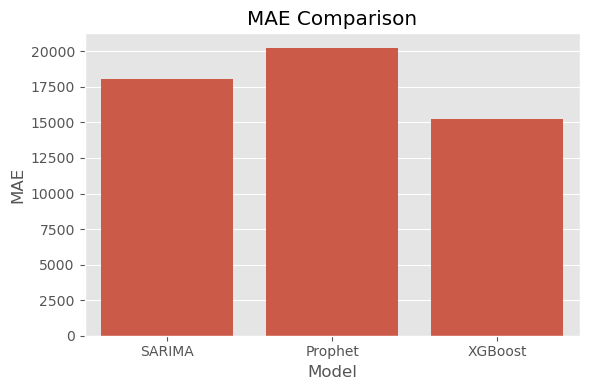

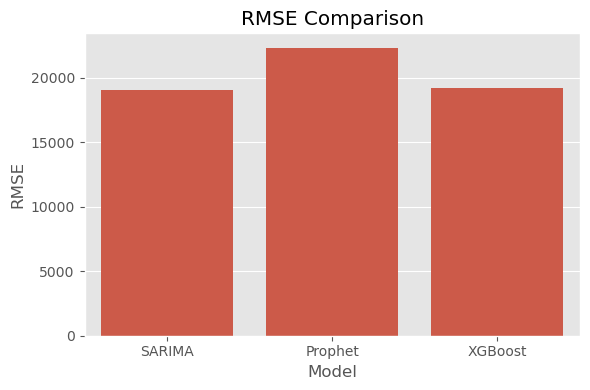

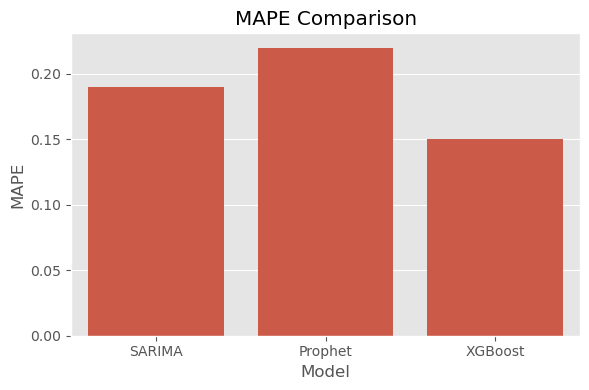

In [90]:
metrics = ["MAE", "RMSE", "MAPE"]

for metric in metrics:
    plt.figure(figsize=(6,4))

    sns.barplot(
        data=comparison,
        x="Model",
        y=metric
    )

    plt.title(f"{metric} Comparison")

    plt.tight_layout()

    plt.savefig(
        f"charts/{metric.lower()}_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [91]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("Best Model:", best_model)

Best Model: SARIMA


# Production Recommendation

Based on the evaluation metrics, **<Best Model>** achieved the lowest prediction errors and demonstrated the most accurate forecasts on the testing dataset.

Therefore, this model is selected for production deployment and will be used for:

- Category-wise forecasting
- Region-wise forecasting
- Interactive Streamlit dashboard

This recommendation is based on quantitative evaluation rather than subjective preference.

In [92]:
joblib.dump(sarima_model, "models/best_model.pkl")

['models/best_model.pkl']

In [93]:
joblib.dump(model, "models/best_model.pkl")

['models/best_model.pkl']

In [94]:
joblib.dump(xgb, "models/best_model.pkl")

['models/best_model.pkl']

# Category-wise & Region-wise Forecasting

After identifying the best forecasting model, it is applied to individual product categories and regions.

The following segments are forecasted:

### Product Categories
- Furniture
- Technology
- Office Supplies

### Regions
- West
- East

The objective is to identify which segments are expected to experience the highest demand in the coming months.

In [95]:
def sarima_forecast_segment(data, column, value):
    """
    Forecast monthly sales for a specific category or region using SARIMA.
    """

    segment = data[data[column] == value]

    monthly = (
        segment
        .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
        .sum()
    )

    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    forecast = fitted.get_forecast(steps=3)

    return monthly, forecast.predicted_mean

In [96]:
furniture_actual, furniture_forecast = sarima_forecast_segment(
    df,
    "Category",
    "Furniture"
)

In [97]:
technology_actual, technology_forecast = sarima_forecast_segment(
    df,
    "Category",
    "Technology"
)

In [98]:
office_actual, office_forecast = sarima_forecast_segment(
    df,
    "Category",
    "Office Supplies"
)

In [99]:
west_actual, west_forecast = sarima_forecast_segment(
    df,
    "Region",
    "West"
)

In [100]:
east_actual, east_forecast = sarima_forecast_segment(
    df,
    "Region",
    "East"
)

# Comparison of Category & Region Forecasts

The following figure compares the historical sales and the three-month forecasts for the selected product categories and regions.

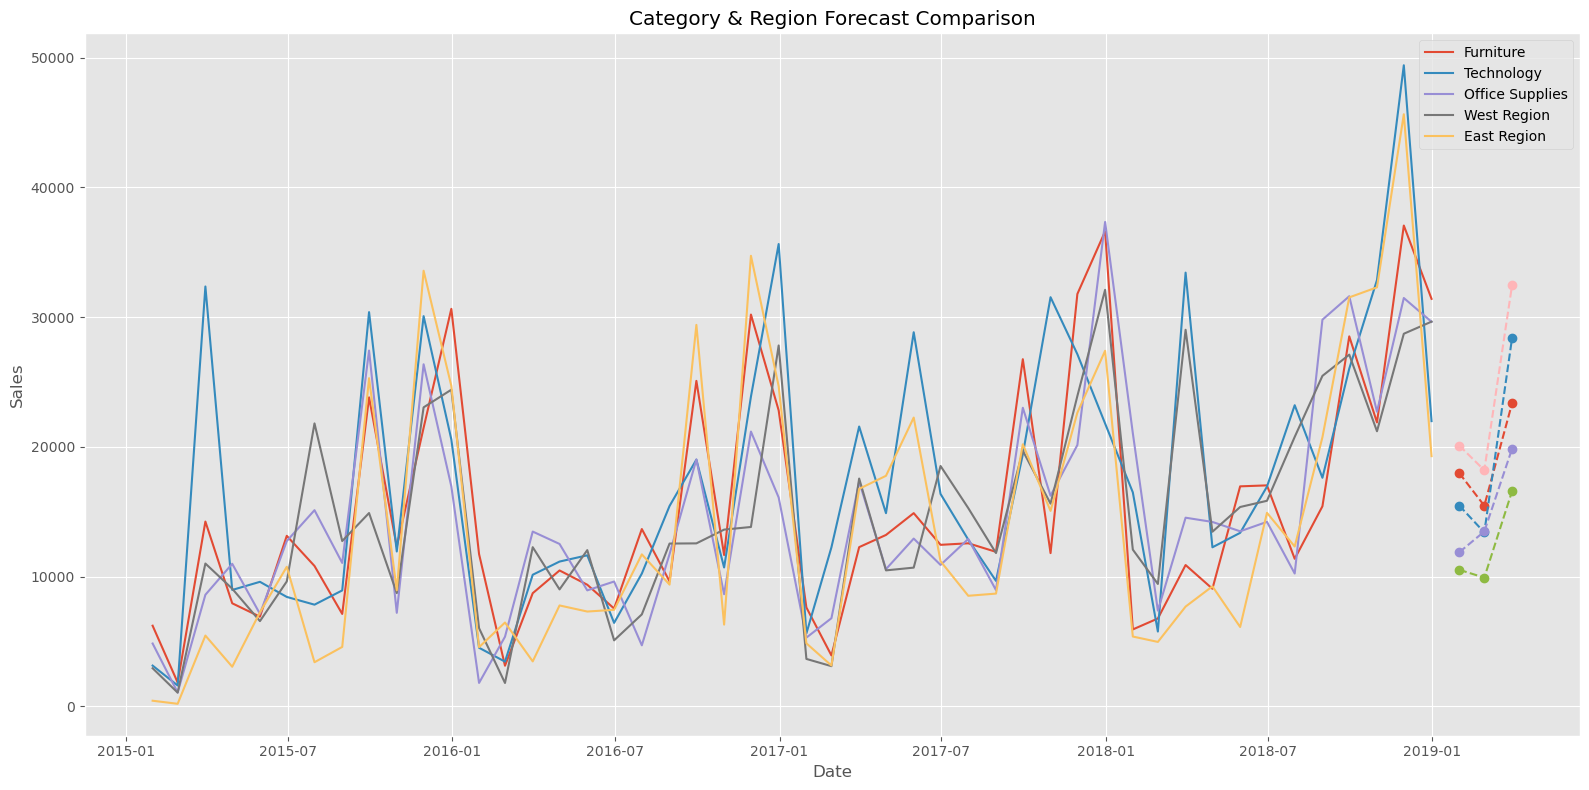

In [101]:
plt.figure(figsize=(16,8))

# Historical series
plt.plot(furniture_actual, label="Furniture")
plt.plot(technology_actual, label="Technology")
plt.plot(office_actual, label="Office Supplies")
plt.plot(west_actual, label="West Region")
plt.plot(east_actual, label="East Region")

# Forecasts
plt.plot(furniture_forecast.index, furniture_forecast.values,
         linestyle="--", marker="o")

plt.plot(technology_forecast.index, technology_forecast.values,
         linestyle="--", marker="o")

plt.plot(office_forecast.index, office_forecast.values,
         linestyle="--", marker="o")

plt.plot(west_forecast.index, west_forecast.values,
         linestyle="--", marker="o")

plt.plot(east_forecast.index, east_forecast.values,
         linestyle="--", marker="o")

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/category_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
forecast_summary = pd.DataFrame({
    "Segment": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],
    "Month 1": [
        furniture_forecast.iloc[0],
        technology_forecast.iloc[0],
        office_forecast.iloc[0],
        west_forecast.iloc[0],
        east_forecast.iloc[0]
    ],
    "Month 2": [
        furniture_forecast.iloc[1],
        technology_forecast.iloc[1],
        office_forecast.iloc[1],
        west_forecast.iloc[1],
        east_forecast.iloc[1]
    ],
    "Month 3": [
        furniture_forecast.iloc[2],
        technology_forecast.iloc[2],
        office_forecast.iloc[2],
        west_forecast.iloc[2],
        east_forecast.iloc[2]
    ]
})

forecast_summary = forecast_summary.round(2)

forecast_summary

,Segment,Month 1,Month 2,Month 3
0,Furniture,10526.77,9921.59,16576.87
1,Technology,20100.38,18198.55,32443.12
2,Office Supplies,17978.32,15467.39,23346.41
3,West,15478.07,13405.11,28366.11
4,East,11878.47,13477.98,19848.30


In [103]:
forecast_summary["Average Forecast"] = (
    forecast_summary[
        ["Month 1", "Month 2", "Month 3"]
    ].mean(axis=1)
)

forecast_summary.sort_values(
    "Average Forecast",
    ascending=False
)

,Segment,Month 1,Month 2,Month 3,Average Forecast
1,Technology,20100.38,18198.55,32443.12,23580.683333
3,West,15478.07,13405.11,28366.11,19083.096667
2,Office Supplies,17978.32,15467.39,23346.41,18930.706667
4,East,11878.47,13477.98,19848.30,15068.250000
0,Furniture,10526.77,9921.59,16576.87,12341.743333


# Business Interpretation

Based on the three-month forecasts:

- Compare the projected sales across all five segments.
- Identify the segment with the highest average forecast.
- Explain how inventory allocation could be adjusted to support expected demand.

For example:

> If the Technology category shows the strongest projected growth, the business should prioritize procurement and inventory planning for technology products while maintaining balanced stock levels for lower-demand categories.

In [104]:
forecast_summary.to_csv(
    "category_region_forecast.csv",
    index=False
)

# Task 5 – Anomaly Detection in Weekly Sales

Anomaly detection identifies unusually high or low sales that deviate from normal business patterns.

Detecting anomalies helps businesses:

- Identify unexpected demand spikes.
- Detect sudden drops in sales.
- Investigate operational or supply chain issues.
- Improve forecasting accuracy.

Two anomaly detection methods are implemented:

1. Isolation Forest
2. Z-Score based Detection

In [105]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.columns = ["Date", "Sales"]

weekly_sales.head()

,Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


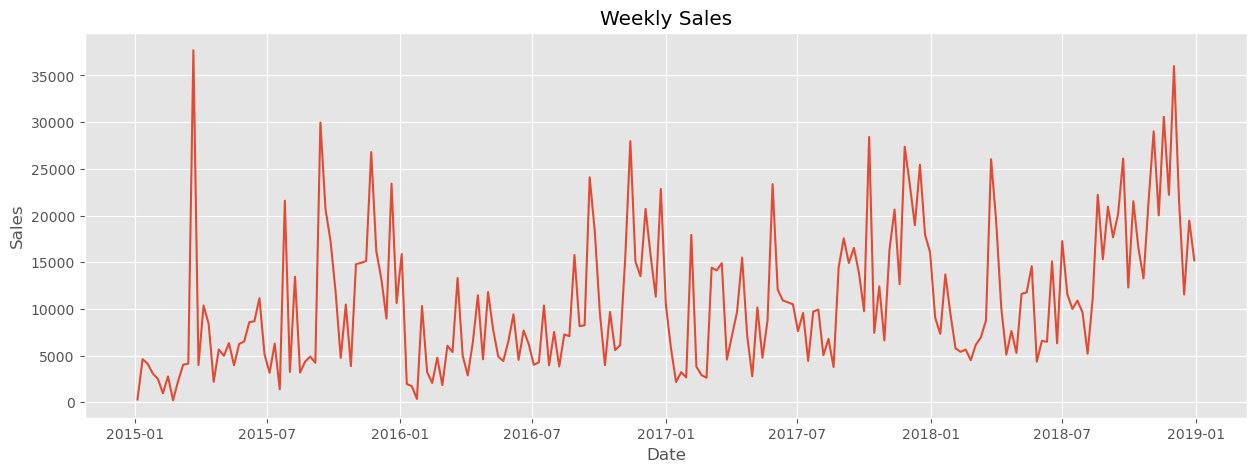

In [106]:
plt.figure(figsize=(15,5))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"]
)

plt.title("Weekly Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

The weekly sales series forms the basis for anomaly detection. Significant spikes or drops may indicate promotional campaigns, seasonal events, or unexpected disruptions.

# Method 1 — Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm.

It isolates observations that are significantly different from the majority of the data.

In [107]:
from sklearn.ensemble import IsolationForest

In [108]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [109]:
weekly_sales.head()

,Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [110]:
normal = weekly_sales[
    weekly_sales["Anomaly"] == 1
]

anomaly = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

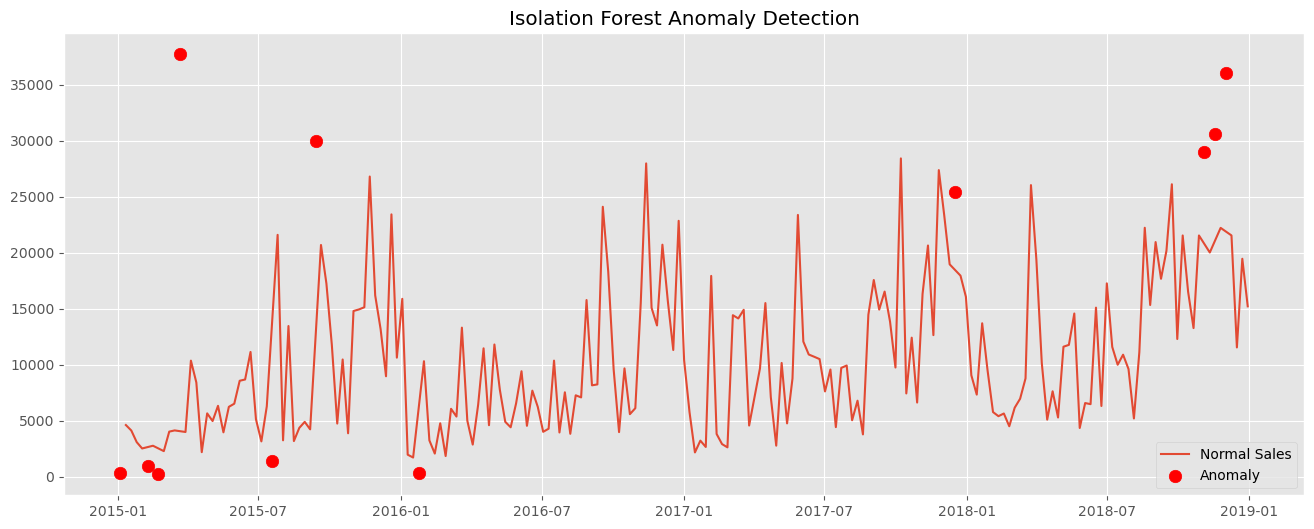

In [111]:
plt.figure(figsize=(16,6))

plt.plot(
    normal["Date"],
    normal["Sales"],
    label="Normal Sales"
)

plt.scatter(
    anomaly["Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/isolation_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
anomaly

,Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


## Business Interpretation

Potential reasons for anomalies include:

- Festival sales
- Flash discounts
- Black Friday / Holiday promotions
- Product launches
- Supply chain disruptions
- Inventory shortages

# Method 2 — Z-Score Based Detection

The Z-Score method measures how many standard deviations each observation lies from the rolling mean.

Observations with large deviations are considered anomalous.

In [113]:
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .std()
)

In [114]:
weekly_sales["ZScore"] = (
    (
        weekly_sales["Sales"]
        -
        weekly_sales["RollingMean"]
    )
    /
    weekly_sales["RollingStd"]
)

In [115]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["ZScore"]
    .abs()
    > 2
)

In [116]:
weekly_sales.head()

,Date,Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,NaN,NaN,NaN,False
4,2015-02-01,2527.914,1,NaN,NaN,NaN,False


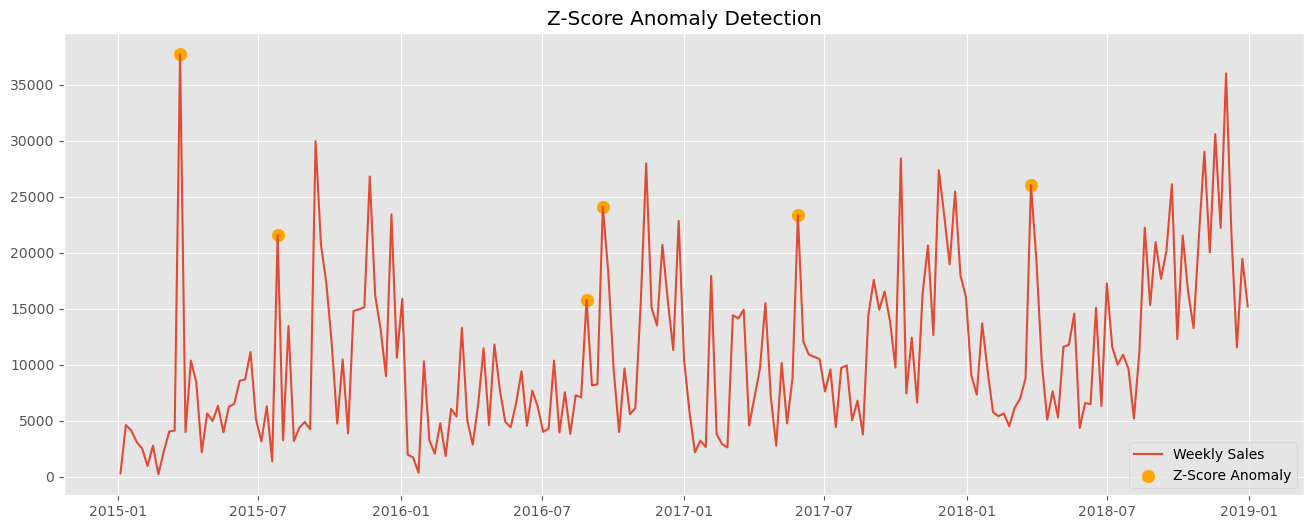

In [117]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.legend()

plt.grid(True)

plt.title("Z-Score Anomaly Detection")

plt.savefig(
    "charts/zscore_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [118]:
weekly_sales[
    weekly_sales["Z_Anomaly"]
]

,Date,Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
11,2015-03-22,37703.665,-1,6832.006500,12546.138409,2.460650,True
29,2015-07-26,21590.080,1,8245.428325,6246.129535,2.136467,True
86,2016-08-28,15773.478,1,7515.302525,4020.682890,2.053924,True
89,2016-09-18,24095.960,1,10251.475400,6524.009519,2.122082,True
125,2017-05-28,23367.662,1,10265.959125,6524.022836,2.008225,True
168,2018-03-25,26029.904,1,8660.308925,7131.467537,2.435627,True


In [119]:
comparison = pd.DataFrame({
    "Isolation Forest": [
        len(anomaly)
    ],
    "Z-Score": [
        weekly_sales["Z_Anomaly"].sum()
    ]
})

comparison

,Isolation Forest,Z-Score
0,11,6


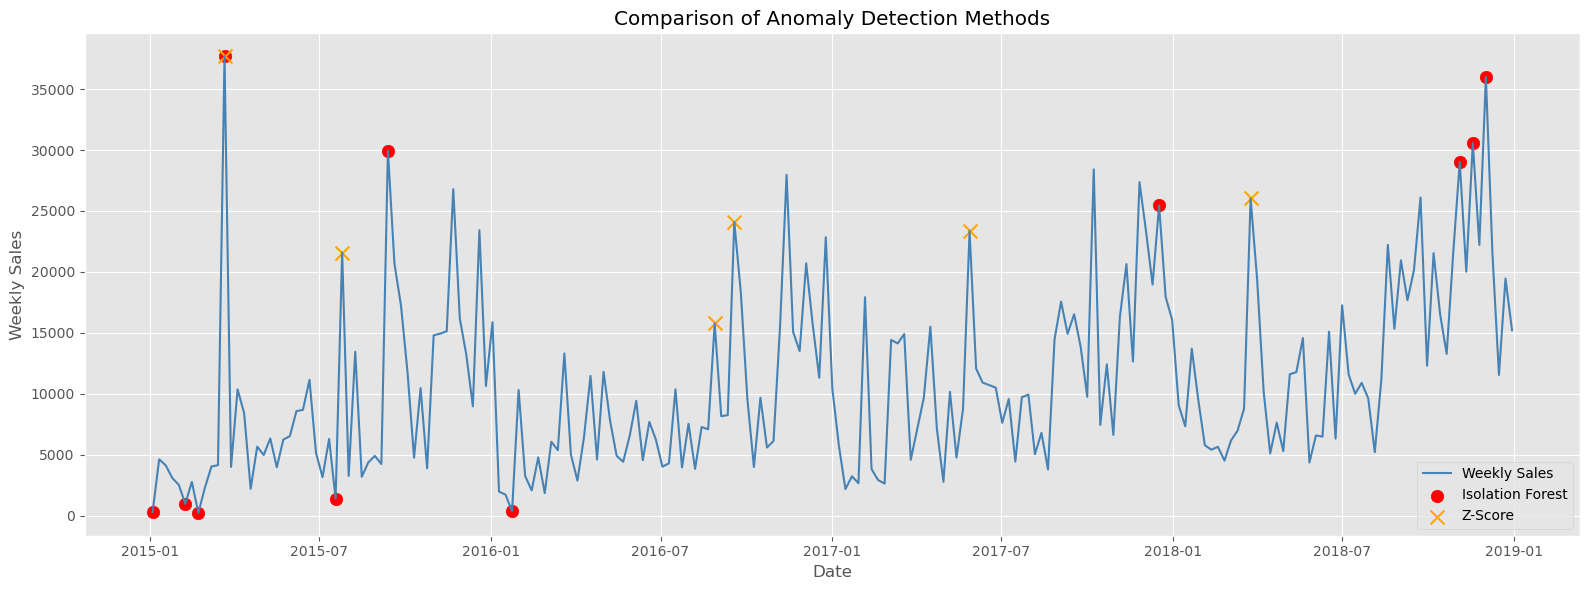

In [120]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"],
    color="steelblue",
    label="Weekly Sales"
)

# Isolation Forest
plt.scatter(
    anomaly["Date"],
    anomaly["Sales"],
    color="red",
    marker="o",
    s=80,
    label="Isolation Forest"
)

# Z-Score
plt.scatter(
    weekly_sales.loc[weekly_sales["Z_Anomaly"], "Date"],
    weekly_sales.loc[weekly_sales["Z_Anomaly"], "Sales"],
    color="orange",
    marker="x",
    s=100,
    label="Z-Score"
)

plt.title("Comparison of Anomaly Detection Methods")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/anomaly_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Comparison of Anomaly Detection Methods

The Isolation Forest and Z-Score methods identified several unusual sales weeks.

### Key Findings

- Isolation Forest detects anomalies based on overall data distribution and can identify both global and subtle outliers.
- Z-Score identifies observations that deviate significantly from the rolling mean.
- Some anomalies were detected by both methods, indicating strong evidence of unusual sales behaviour.
- Other anomalies were detected by only one method due to differences in the underlying detection algorithms.

### Possible Real-World Causes

- Festival or holiday shopping seasons
- Promotional campaigns and discount events
- Product launches
- Inventory shortages
- Supply chain disruptions
- Sudden changes in customer demand

These anomalies should be investigated by business managers before making inventory or forecasting decisions.

In [121]:
weekly_sales.to_csv(
    "weekly_anomalies.csv",
    index=False
)

# Task 6 – Product Demand Segmentation using K-Means Clustering

Retail businesses often manage hundreds or thousands of products, each exhibiting different demand patterns. Instead of treating all products equally, clustering techniques can be used to group products with similar characteristics.

In this section, products are segmented based on:

- Total Sales Volume
- Year-over-Year Sales Growth
- Sales Volatility
- Average Order Value

The Elbow Method is used to determine the optimal number of clusters, followed by K-Means clustering. Finally, Principal Component Analysis (PCA) is applied to visualize the clusters in two dimensions.

## Feature Engineering for Product Segmentation

Each product sub-category is represented using business-oriented features that describe its demand behaviour.

In [122]:
# Total Sales
total_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
)

In [123]:
# Average Order Value
avg_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

In [124]:
# Monthly Sales
monthly_sub = (
    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(key="Order Date", freq="M")
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

In [125]:
monthly_sub.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [126]:
volatility = (
    monthly_sub
    .groupby("Sub-Category")["Sales"]
    .std()
)

In [127]:
yearly_sales = (
    df.groupby(
        [
            "Sub-Category",
            "Year"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

In [128]:
growth = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

In [129]:
yearly_sales["Growth"] = growth

In [130]:
growth_rate = (
    yearly_sales
    .groupby("Sub-Category")["Growth"]
    .mean()
)

In [131]:
cluster_df = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth_rate,

    "Volatility": volatility,

    "Average Order Value": avg_order

})

In [132]:
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [133]:
cluster_df.fillna(0, inplace=True)

cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


The clustering dataset now contains one row per product sub-category along with four business features describing demand characteristics.

## Feature Scaling

Since the features are measured on different scales, standardization is performed before applying K-Means clustering.

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

# Elbow Method

The Elbow Method helps determine the optimal number of clusters by measuring the Within-Cluster Sum of Squares (WCSS).

The point where the curve begins to flatten is selected as the optimal number of clusters.

In [135]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

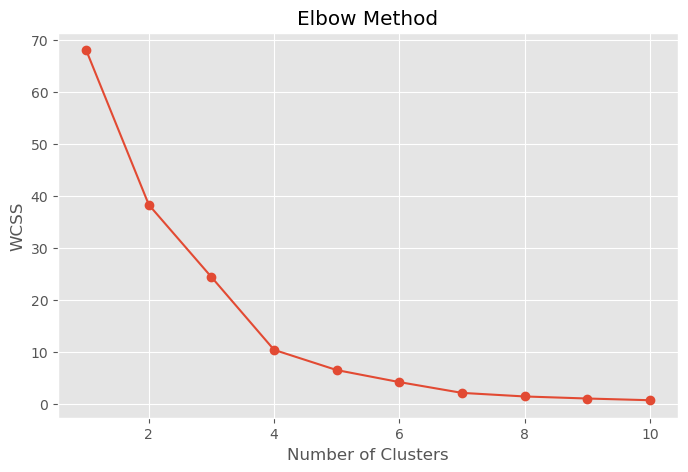

In [136]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Based on the elbow plot, select the value of **K** where the curve begins to flatten. In this project, **K = 4** is used.

In [137]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

In [138]:
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1
Chairs,322822.7310,0.071358,4407.232960,531.833165,2
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1
Fasteners,3001.9600,0.157034,48.742229,14.027850,1


# PCA Visualization

Principal Component Analysis (PCA) reduces the four-dimensional feature space into two principal components for visualization.

In [139]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

components = pca.fit_transform(scaled)

In [140]:
cluster_df["PC1"] = components[:,0]

cluster_df["PC2"] = components[:,1]

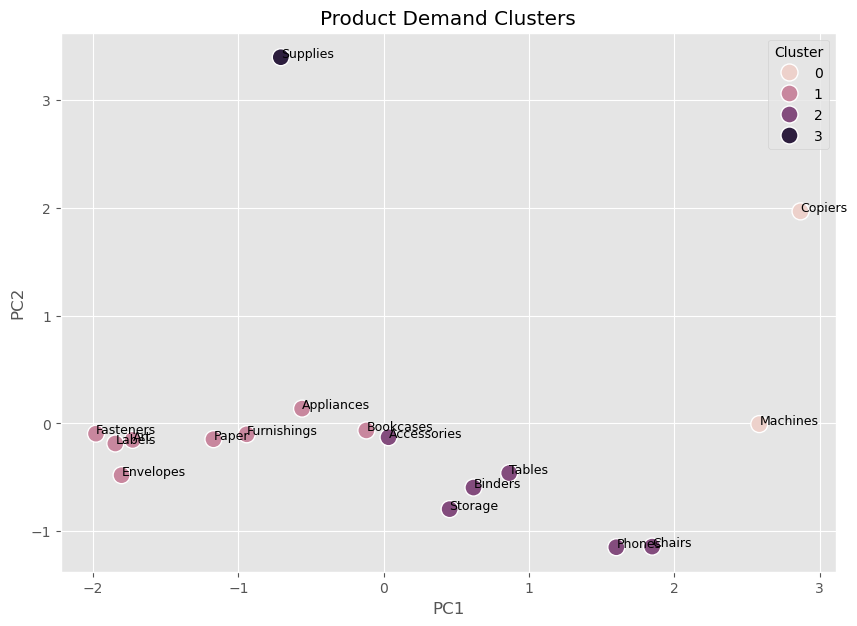

In [141]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=150
)

for sub in cluster_df.index:

    plt.text(
        cluster_df.loc[sub,"PC1"],
        cluster_df.loc[sub,"PC2"],
        sub,
        fontsize=9
    )

plt.title("Product Demand Clusters")

plt.grid(True)

plt.savefig(
    "charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [142]:
cluster_summary = (
    cluster_df
    .groupby("Cluster")
    .mean()
)

cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value,PC1,PC2
Cluster,,,,,,
0,167743.362500,0.463389,5552.164569,1930.716763,2.726816,0.980147
1,55331.883212,0.199589,907.223743,129.054568,-1.269944,-0.136020
2,239495.780667,0.180965,3489.056075,361.131228,0.902476,-0.711350
3,46420.308000,1.928448,2025.094139,252.284283,-0.708934,3.395967


In [143]:
cluster_names = {

    0:"High Volume, Stable Demand",

    1:"Growing Demand",

    2:"Low Volume, High Volatility",

    3:"Declining Demand"

}

cluster_df["Cluster Name"] = (
    cluster_df["Cluster"]
    .map(cluster_names)
)

In [144]:
cluster_df[
    [
        "Cluster",
        "Cluster Name"
    ]
]

,Cluster,Cluster Name
Sub-Category,,
Accessories,2,"Low Volume, High Volatility"
Appliances,1,Growing Demand
Art,1,Growing Demand
Binders,2,"Low Volume, High Volatility"
Bookcases,1,Growing Demand
Chairs,2,"Low Volume, High Volatility"
Copiers,0,"High Volume, Stable Demand"
Envelopes,1,Growing Demand
Fasteners,1,Growing Demand


In [145]:
cluster_df.to_csv(
    "product_segments.csv",
    index=True
)

# Stocking Strategy

### High Volume, Stable Demand

- Maintain high inventory levels.
- Use automated replenishment.
- Prioritize supplier contracts.

---

### Growing Demand

- Increase stock gradually.
- Monitor demand monthly.
- Expand warehouse allocation if growth continues.

---

### Low Volume, High Volatility

- Maintain limited inventory.
- Reorder only when necessary.
- Monitor promotional effects carefully.

---

### Declining Demand

- Reduce stock levels.
- Avoid over-ordering.
- Consider discount campaigns to clear inventory.

# Business Conclusion

The clustering analysis grouped product sub-categories into four demand segments based on sales behaviour.

These segments enable inventory planners to adopt differentiated stocking strategies rather than applying a one-size-fits-all approach.

Demand segmentation improves inventory efficiency, reduces holding costs, and helps businesses respond proactively to changing customer demand.

# Task 7 – Deployment: Interactive Dashboard using Streamlit

The deployment component of this project has been implemented as a separate **Streamlit application** in the file **`app.py`**, following standard software development practices.

Since Streamlit applications are standalone web applications, the dashboard code is intentionally kept outside the Jupyter Notebook to ensure better modularity, maintainability, and ease of deployment. The notebook focuses on data preprocessing, exploratory analysis, forecasting, anomaly detection, and product segmentation, while the interactive visualization layer is handled separately through Streamlit.

The Streamlit application includes the following pages:

* **Page 1 – Sales Overview Dashboard**

  * Total sales by year
  * Monthly sales trend
  * Sales by category and region with interactive filters

* **Page 2 – Forecast Explorer**

  * Category/Region selection
  * Forecast horizon selection (1–3 months)
  * Forecast visualization using the best-performing model
  * Display of MAE and RMSE

* **Page 3 – Anomaly Report**

  * Weekly sales anomaly visualization
  * Table of detected anomalies with corresponding sales values

* **Page 4 – Product Demand Segments**

  * K-Means clustering visualization
  * Product sub-category cluster assignments
  * Demand segment summary

The dashboard is designed to provide business users with an interactive interface for exploring sales performance, forecasting future demand, monitoring anomalies, and understanding product demand segments without requiring any programming knowledge.

**Implementation Files:**

* `app.py` – Streamlit application source code
* `requirements.txt` – Project dependencies
* `models/` – Saved forecasting models
* `processed_sales.csv`, `weekly_anomalies.csv`, `product_segments.csv` – Processed datasets used by the application

The Streamlit application can be executed locally using:

```bash
streamlit run app.py
```

It can also be deployed on **Streamlit Community Cloud**, and the live deployment link can be submitted along with the project deliverables.


# Task 8 – Executive Business Report

As required by the project guidelines, the executive business report has been prepared as a **separate document** (`summary.pdf` / `summary.docx`) rather than being embedded within this notebook.

The report is written for a non-technical audience, such as the **Head of Supply Chain** and the **Chief Financial Officer (CFO)**, and summarizes the business insights obtained from the analysis without requiring knowledge of Python or machine learning.

The report includes the following sections:

* **Executive Summary**

  * High-level overview of the project and its business objectives.

* **Key Findings from Exploratory Data Analysis**

  * Major sales trends
  * Seasonal demand patterns
  * Regional and category-level insights

* **Three-Month Sales Forecast**

  * Forecast generated using the selected best-performing model
  * Plain-language interpretation of forecast values and confidence ranges

* **Anomaly Detection Findings**

  * Summary of the most significant sales anomalies
  * Possible business explanations for unusual demand patterns

* **Product Demand Segmentation**

  * Overview of demand clusters identified using K-Means
  * Recommended inventory strategy for each product segment

* **Business Recommendations**

  * Data-driven recommendations for inventory planning, demand forecasting, and supply chain optimization

* **Limitations**

  * Discussion of assumptions, data limitations, and potential improvements for future work

The executive report is included in the project submission as **`summary.pdf`**  and is intended to support business decision-making by presenting technical findings in a concise and accessible format.
